# Strategie ewolucyjne

Notebook pokazuje podstawowe mechanizmy strategii ewolucyjnych.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib import cm

%matplotlib inline

## Przykładowe problemy testowe

In [2]:
# Sphere function (minimum at 0)
def objective_function_F1(X):
    return -np.sum(X**2, axis=1)


# Sphere function - modified
def objective_function_F1a(X):
    return -(X[:, 0] ** 2 + 9 * X[:, 1] ** 2)


# Sphere function - modified
def objective_function_F1b(X):
    return -(X[:, 0] ** 2 + 625 * X[:, 1] ** 2)


# Sphere function - modified
def objective_function_F1c(X):
    return -(X[:, 0] ** 2 + 2 * X[:, 1] ** 2 - 2 * X[:, 0] * X[:, 1])

In [3]:
# Rastrigin function (minimum at 0)
def objective_function_F6(X):
    return (
        -10.0 * X.shape[1]
        - np.sum(X**2, axis=1)
        + 10.0 * np.sum(np.cos(2 * np.pi * X), axis=1)
    )

In [4]:
# Schwefel function (minimum at 420.9687)
# (REMARK: should be considered only on [-500, 500]^d, because there are better minima outside)
def objective_function_F7(X):
    return -418.9829 * X.shape[1] + np.sum(X * np.sin(np.sqrt(np.abs(X))), axis=1)

In [5]:
# Griewank function (minimum at 0)
def objective_function_F8(X):
    return (
        -1
        - np.sum(X**2 / 4000, axis=1)
        + np.prod(np.cos(X / np.sqrt(np.linspace(1, X.shape[1], X.shape[1]))), axis=1)
    )

In [6]:
def plot_3D_benchmark_function(objective_function, domain_X, domain_Y, title):
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(projection="3d")
    X, Y = np.meshgrid(domain_X, domain_Y)
    Z = -objective_function(np.vstack([X.ravel(), Y.ravel()]).T).reshape(
        X.shape[0], X.shape[1]
    )
    surf = ax.plot_surface(
        X, Y, Z, rstride=1, cstride=1, cmap=cm.hot, linewidth=0, antialiased=True
    )
    plt.title(title)
    plt.show()

In [7]:
def plot_contour_benchmark_function(objective_function, domain_X, domain_Y, title):
    plt.figure(figsize=(9, 9))
    X, Y = np.meshgrid(domain_X, domain_Y)
    Z = -objective_function(np.vstack([X.ravel(), Y.ravel()]).T).reshape(
        X.shape[0], X.shape[1]
    )
    plt.contour(X, Y, Z, 50)
    plt.title(title)
    plt.show()

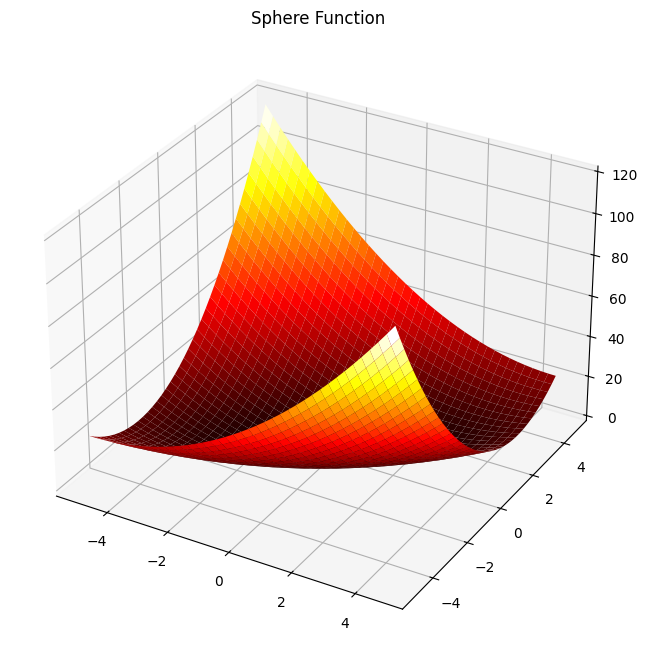

In [8]:
plot_3D_benchmark_function(
    objective_function_F1c,
    np.arange(-5, 5, 0.25),
    np.arange(-5, 5, 0.25),
    "Sphere Function",
)

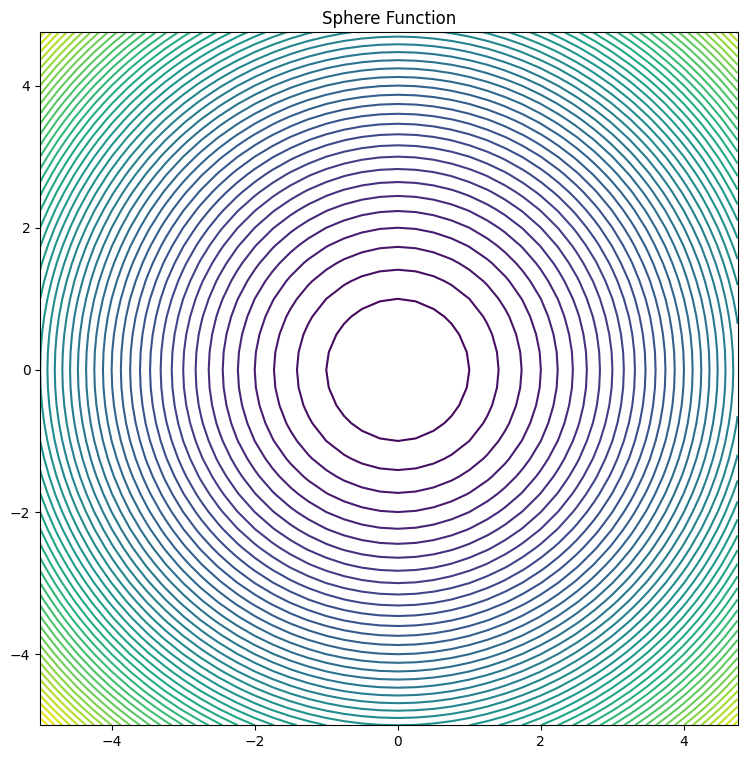

In [9]:
plot_contour_benchmark_function(
    objective_function_F1,
    np.arange(-5, 5, 0.25),
    np.arange(-5, 5, 0.25),
    "Sphere Function",
)

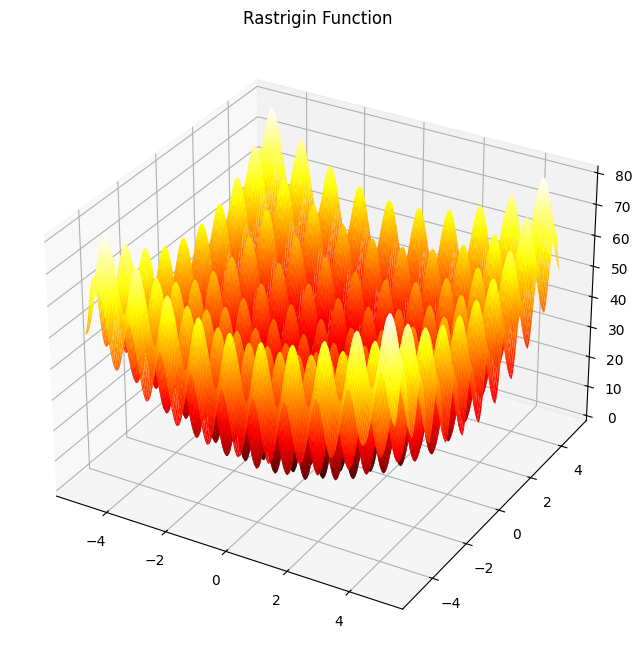

In [10]:
plot_3D_benchmark_function(
    objective_function_F6,
    np.arange(-5, 5, 0.05),
    np.arange(-5, 5, 0.05),
    "Rastrigin Function",
)

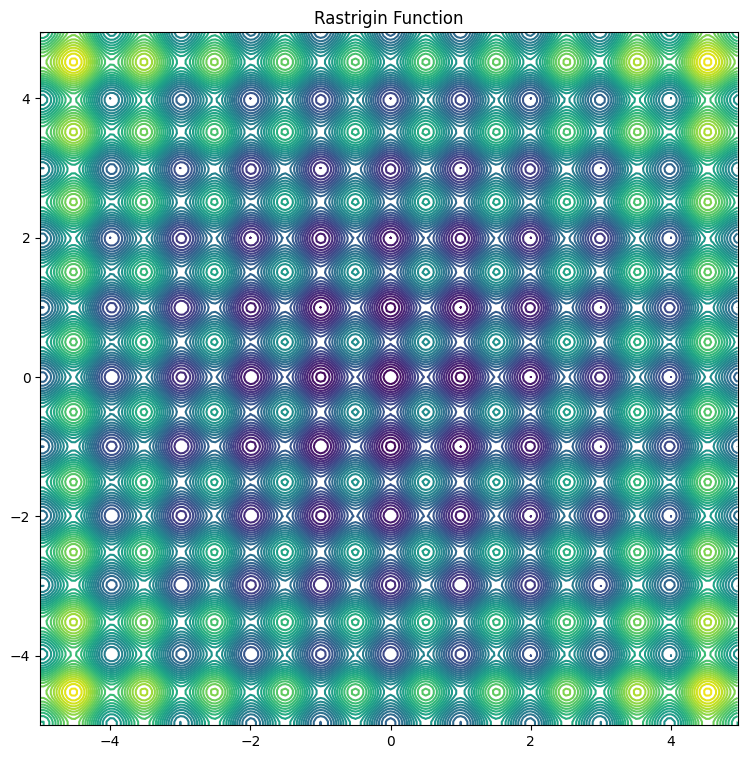

In [11]:
plot_contour_benchmark_function(
    objective_function_F6,
    np.arange(-5, 5, 0.05),
    np.arange(-5, 5, 0.05),
    "Rastrigin Function",
)

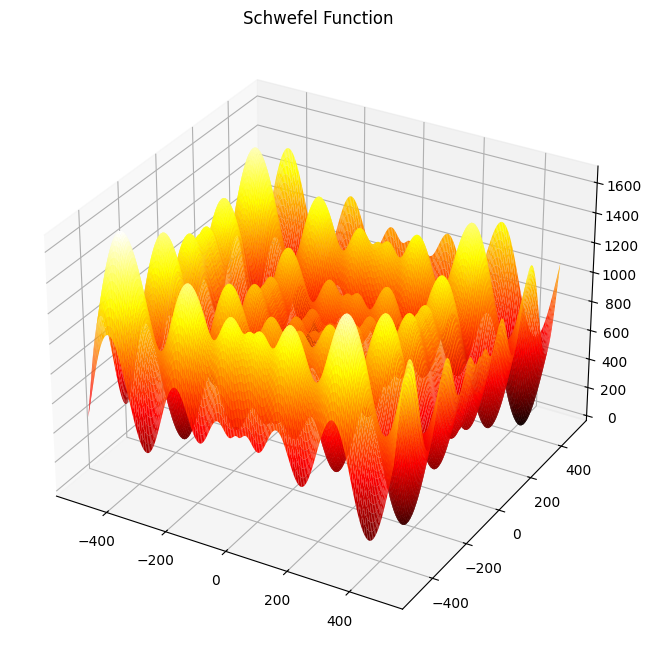

In [12]:
plot_3D_benchmark_function(
    objective_function_F7,
    np.arange(-500, 500, 5),
    np.arange(-500, 500, 5),
    "Schwefel Function",
)

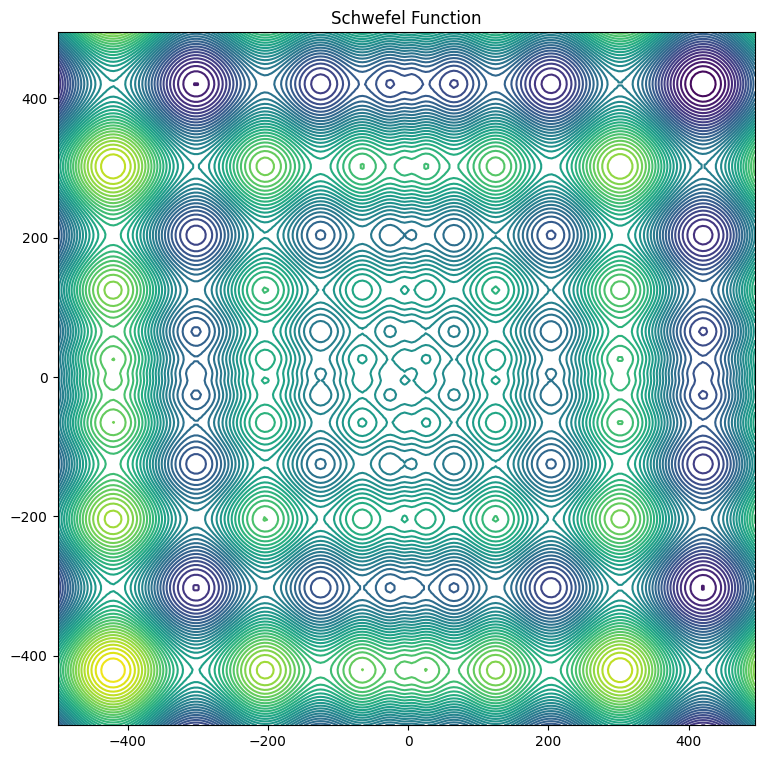

In [13]:
plot_contour_benchmark_function(
    objective_function_F7,
    np.arange(-500, 500, 5),
    np.arange(-500, 500, 5),
    "Schwefel Function",
)

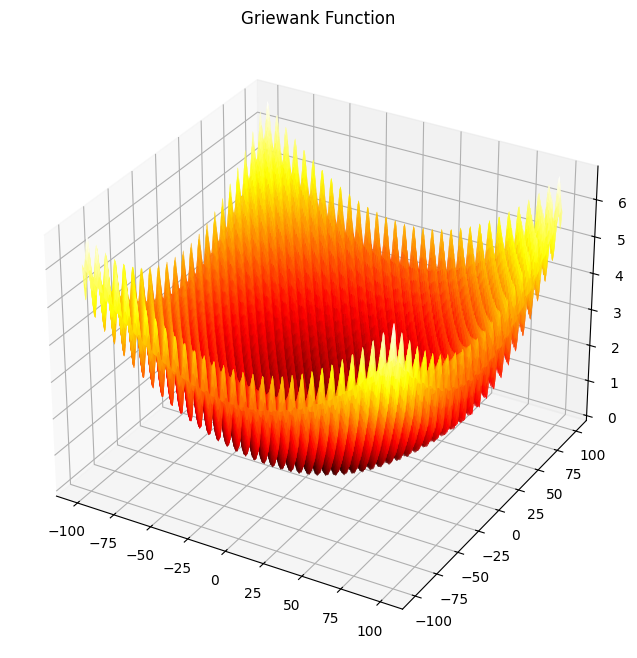

In [14]:
plot_3D_benchmark_function(
    objective_function_F8,
    np.arange(-100, 100, 0.5),
    np.arange(-100, 100, 0.5),
    "Griewank Function",
)

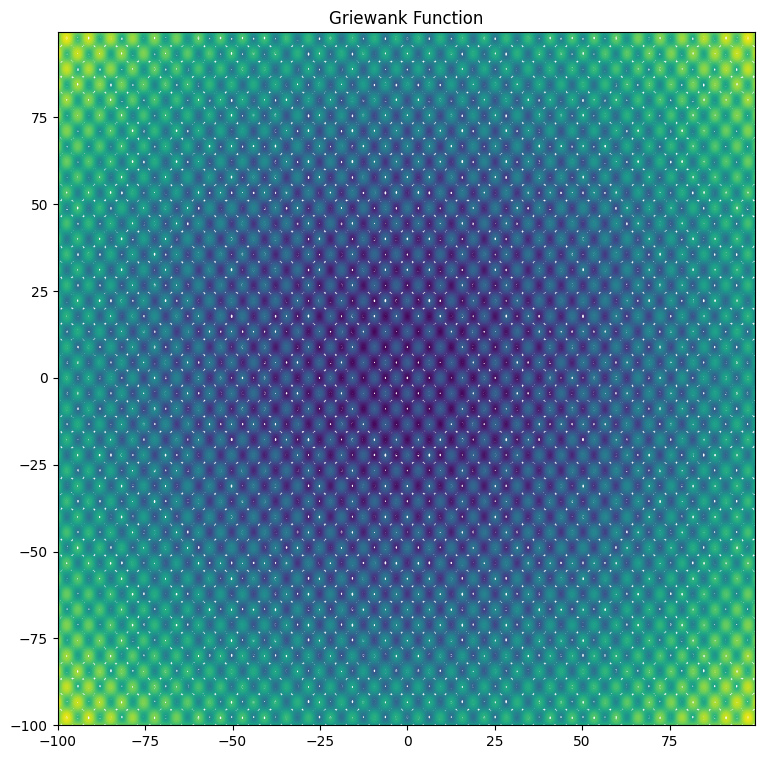

In [15]:
plot_contour_benchmark_function(
    objective_function_F8,
    np.arange(-100, 100, 0.5),
    np.arange(-100, 100, 0.5),
    "Griewank Function",
)

## Przykładowe modele mutacji

In [16]:
N = 250
d = 2

objective_function = objective_function_F1a

original_individual = np.array([[1, 1]])

### Przykład 1:

$x_i = x_i + \varepsilon_i$, gdzie $\varepsilon_i$ ma rozkład normalny $\mathcal{N}(0, \sigma^2)$, zaś $\sigma$ jest taka sama dla wszystkich $i = 1, 2, \ldots, d$

In [17]:
sigma = 0.25
mutations = original_individual + sigma * np.random.randn(N, d)

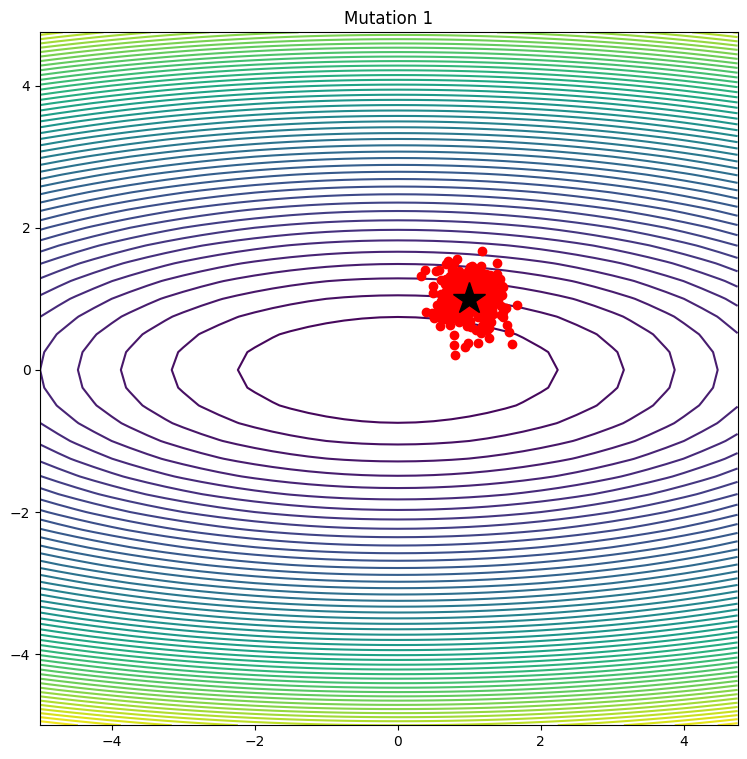

In [18]:
domain_X = np.arange(-5, 5, 0.25)
domain_Y = np.arange(-5, 5, 0.25)
X, Y = np.meshgrid(domain_X, domain_Y)
Z = -objective_function(np.vstack([X.ravel(), Y.ravel()]).T).reshape(
    X.shape[0], X.shape[1]
)

plt.figure(figsize=(9, 9))
plt.contour(X, Y, Z, 50)
plt.plot(mutations[:, 0], mutations[:, 1], "ro")
plt.plot(original_individual[0, 0], original_individual[0, 1], "k*", markersize=24)
plt.title("Mutation 1")
plt.show()

### Przykład 2:

$x_i = x_i + \varepsilon_i$, gdzie $\varepsilon_i$ ma rozkład normalny $\mathcal{N}(0, \sigma_i^2)$, zaś $\sigma_i$ może być różna dla różnych $i = 1, 2, \ldots, d$

In [19]:
sigma = np.array([0.01, 1])
mutations = original_individual + sigma * np.random.randn(N, d)

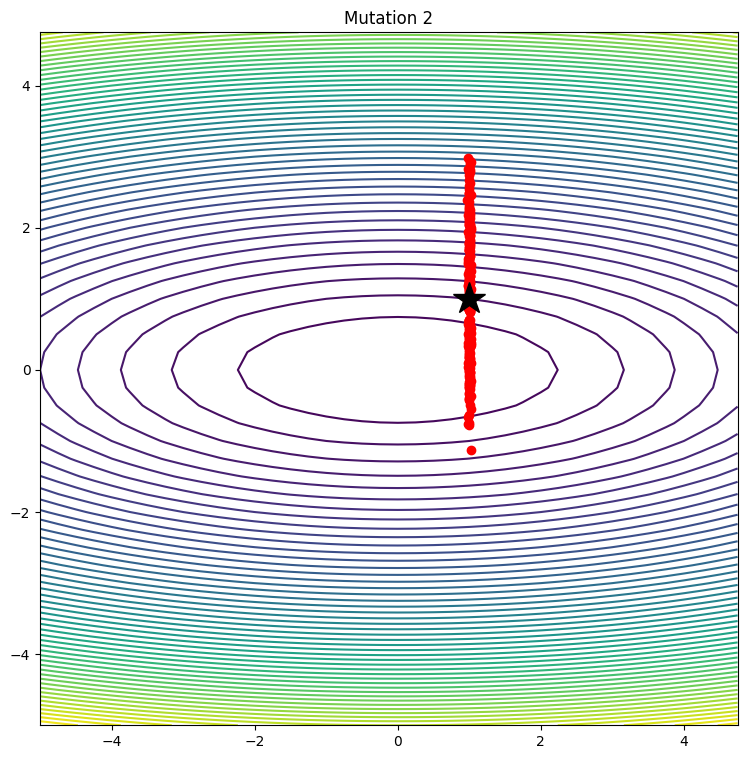

In [20]:
domain_X = np.arange(-5, 5, 0.25)
domain_Y = np.arange(-5, 5, 0.25)
X, Y = np.meshgrid(domain_X, domain_Y)
Z = -objective_function(np.vstack([X.ravel(), Y.ravel()]).T).reshape(
    X.shape[0], X.shape[1]
)

plt.figure(figsize=(9, 9))
plt.contour(X, Y, Z, 50)
plt.plot(mutations[:, 0], mutations[:, 1], "ro")
plt.plot(original_individual[0, 0], original_individual[0, 1], "k*", markersize=24)
plt.title("Mutation 2")
plt.show()

### Przykład 3:

$\mathbf{x} = \mathbf{x} + \boldsymbol{\varepsilon}$, gdzie $\boldsymbol{\varepsilon}$ ma wielowymiarowy rozkład normalny $\mathcal{N}(\mathbf{0}, \boldsymbol{\Sigma})$

In [21]:
S = np.array([[0.25, 0.25], [0.25, 0.5]])
mutations = original_individual + np.dot(np.random.randn(N, d), np.linalg.cholesky(S).T)

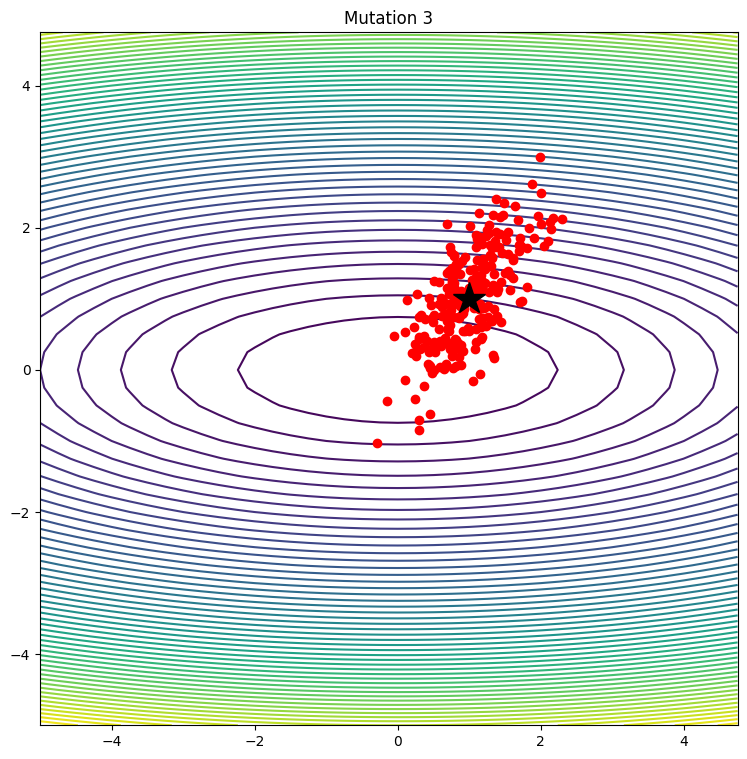

In [22]:
domain_X = np.arange(-5, 5, 0.25)
domain_Y = np.arange(-5, 5, 0.25)
X, Y = np.meshgrid(domain_X, domain_Y)
Z = -objective_function(np.vstack([X.ravel(), Y.ravel()]).T).reshape(
    X.shape[0], X.shape[1]
)

plt.figure(figsize=(9, 9))
plt.contour(X, Y, Z, 50)
plt.plot(mutations[:, 0], mutations[:, 1], "ro")
plt.plot(original_individual[0, 0], original_individual[0, 1], "k*", markersize=24)
plt.title("Mutation 3")
plt.show()

## Przykładowa strategia ewolucyjna

In [23]:
def es(
    objective_function,
    chromosome_length,
    population_size,
    number_of_iterations,
    number_of_offspring,
    number_of_parents,
    sigma,
    tau,
    tau_0,
    S=None,
    mutation_f="mutation_2",
    log_frequency=1,
):
    best_solution = np.empty((1, chromosome_length))
    best_solution_objective_value = -np.inf

    log_objective_values = np.empty((number_of_iterations, 4))
    log_best_solutions = np.empty((number_of_iterations, chromosome_length))
    log_best_sigmas = np.empty((number_of_iterations, chromosome_length))

    # generating an initial population
    current_population_solutions = 100.0 * np.random.rand(
        population_size, chromosome_length
    )

    if mutation_f == "mutation_1":
        current_population_sigmas = sigma * np.ones((population_size, 1))
    elif mutation_f == "mutation_2":
        current_population_sigmas = sigma * np.ones(
            (population_size, chromosome_length)
        )
    elif mutation_f == "mutation_3":
        L_T = np.linalg.cholesky(S).T
        current_population_sigmas = sigma * np.ones((population_size, 1))

    # evaluating the objective function on the current population
    current_population_objective_values = objective_function(
        current_population_solutions
    )

    for t in range(number_of_iterations):
        # selecting the parent indices by the roulette wheel method
        fitness_values = (
            current_population_objective_values
            - current_population_objective_values.min()
        )
        if fitness_values.sum() > 0:
            fitness_values = fitness_values / fitness_values.sum()
        else:
            fitness_values = 1.0 / population_size * np.ones(population_size)
        parent_indices = np.random.choice(
            population_size,
            (number_of_offspring, number_of_parents),
            True,
            fitness_values,
        ).astype(np.int64)

        # creating the children population by Global Intermediere Recombination
        children_population_solutions = np.zeros(
            (number_of_offspring, chromosome_length)
        )
        # dynamic shape based on mutation type
        if mutation_f == "mutation_1" or mutation_f == "mutation_3":
            children_population_sigmas = np.zeros((number_of_offspring, 1))
        else:
            children_population_sigmas = np.zeros(
                (number_of_offspring, chromosome_length)
            )
        for i in range(number_of_offspring):
            children_population_solutions[i, :] = current_population_solutions[
                parent_indices[i, :], :
            ].mean(axis=0)
            children_population_sigmas[i, :] = current_population_sigmas[
                parent_indices[i, :], :
            ].mean(axis=0)

        # mutating the children population by adding random gaussian noise
        if mutation_f == "mutation_1" or mutation_f == "mutation_3":
            children_population_sigmas = children_population_sigmas * np.exp(
                tau * np.random.randn(number_of_offspring, 1)
                + tau_0 * np.random.randn(number_of_offspring, 1)
            )
        elif mutation_f == "mutation_2":
            children_population_sigmas = children_population_sigmas * np.exp(
                tau * np.random.randn(number_of_offspring, chromosome_length)
                + tau_0 * np.random.randn(number_of_offspring, 1)
            )

        if mutation_f == "mutation_1" or mutation_f == "mutation_2":
            children_population_solutions = (
                children_population_solutions
                + children_population_sigmas
                * np.random.randn(number_of_offspring, chromosome_length)
            )
        elif mutation_f == "mutation_3":
            Z = np.random.randn(number_of_offspring, chromosome_length)
            children_population_solutions = (
                children_population_solutions
                + children_population_sigmas * np.dot(Z, L_T)
            )

        # evaluating the objective function on the children population
        children_population_objective_values = objective_function(
            children_population_solutions
        )

        # replacing the current population by (Mu + Lambda) Replacement
        current_population_objective_values = np.hstack(
            [current_population_objective_values, children_population_objective_values]
        )
        current_population_solutions = np.vstack(
            [current_population_solutions, children_population_solutions]
        )
        current_population_sigmas = np.vstack(
            [current_population_sigmas, children_population_sigmas]
        )

        I = np.argsort(current_population_objective_values)[::-1]
        current_population_solutions = current_population_solutions[
            I[:population_size], :
        ]
        current_population_sigmas = current_population_sigmas[I[:population_size], :]
        current_population_objective_values = current_population_objective_values[
            I[:population_size]
        ]

        # recording some statistics
        if best_solution_objective_value < current_population_objective_values[0]:
            best_solution = current_population_solutions[0, :]
            best_solution_objective_value = current_population_objective_values[0]
        log_objective_values[t, :] = [
            current_population_objective_values.min(),
            current_population_objective_values.max(),
            current_population_objective_values.mean(),
            current_population_objective_values.std(),
        ]
        log_best_solutions[t, :] = current_population_solutions[0, :]
        if mutation_f == "mutation_1" or mutation_f == "mutation_3":
            log_best_sigmas[t, :] = current_population_sigmas[0, 0]
        else:
            log_best_sigmas[t, :] = current_population_sigmas[0, :]

        if log_frequency != -1 and np.mod(t, log_frequency) == 0:
            print(
                "Iteration %04d : best score = %0.8f, mean score = %0.8f."
                % (
                    t,
                    log_objective_values[: t + 1, 1].max(),
                    log_objective_values[t, 2],
                )
            )

    return (
        best_solution_objective_value,
        best_solution,
        log_objective_values,
        log_best_solutions,
        log_best_sigmas,
    )

### Działanie strategii ewolucyjnej dla funkcji sferycznej F1

Iteration 0000 : best score = -5890.70128146, mean score = -26598.62022926.
Iteration 0001 : best score = -3303.48509343, mean score = -20982.18381316.
Iteration 0002 : best score = -3177.23329171, mean score = -14897.01258000.
Iteration 0003 : best score = -2028.93414676, mean score = -9561.78764417.
Iteration 0004 : best score = -1000.90802458, mean score = -5976.01327437.
Iteration 0005 : best score = -727.62979324, mean score = -3642.26874840.
Iteration 0006 : best score = -446.63603995, mean score = -2195.29701252.
Iteration 0007 : best score = -274.84093752, mean score = -1300.99707489.
Iteration 0008 : best score = -116.60309960, mean score = -765.15092484.
Iteration 0009 : best score = -78.16235832, mean score = -442.47308650.
Iteration 0010 : best score = -24.50271751, mean score = -248.42754217.
Iteration 0011 : best score = -18.64917502, mean score = -139.45592797.
Iteration 0012 : best score = -3.55350308, mean score = -78.95801380.
Iteration 0013 : best score = -3.55350308

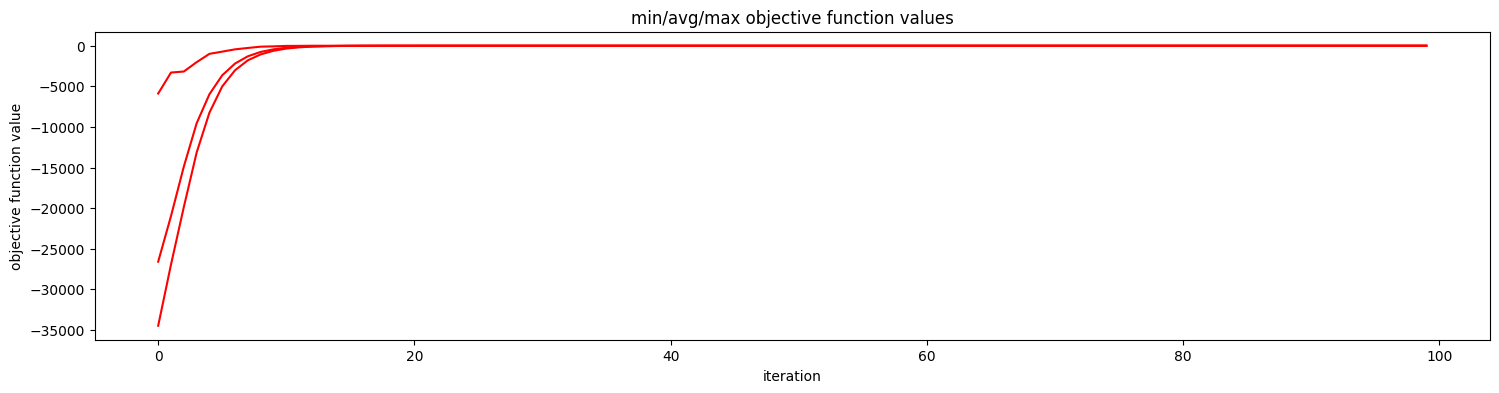

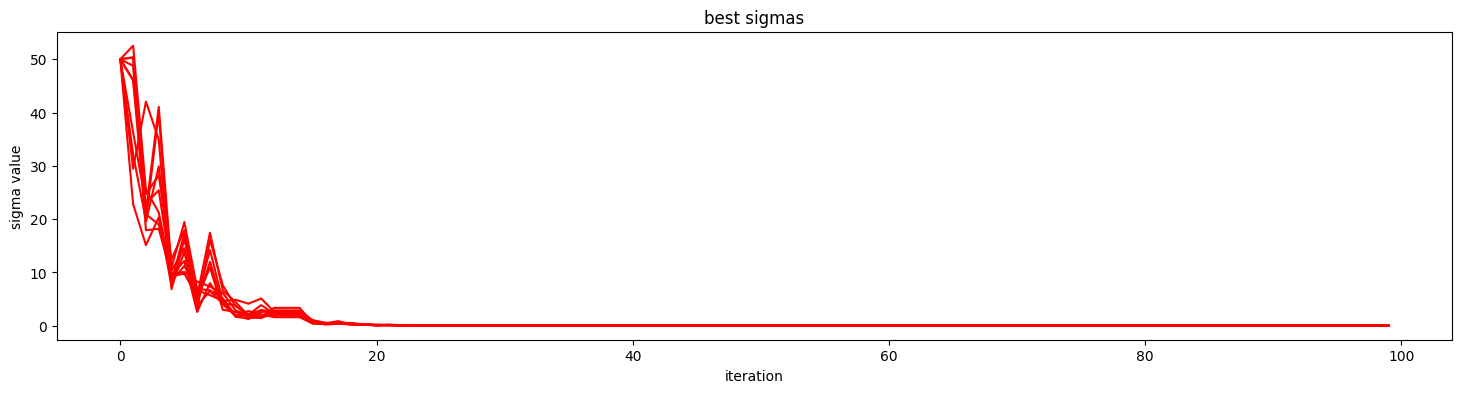

In [24]:
d = 10
N = 2000
T = 100

(
    best_objective_value,
    best_chromosome,
    history_objective_values,
    history_best_chromosome,
    history_best_sigmas,
) = es(
    objective_function_F1,
    d,
    N,
    T,
    2 * N,
    2,
    50.0,
    1 / np.sqrt(2 * d),
    1 / np.sqrt(2 * np.sqrt(d)),
    10,
)

plt.figure(figsize=(18, 4))
plt.plot(history_objective_values[:, 0], "r-")
plt.plot(history_objective_values[:, 1], "r-")
plt.plot(history_objective_values[:, 2], "r-")
plt.xlabel("iteration")
plt.ylabel("objective function value")
plt.title("min/avg/max objective function values")
plt.show()

plt.figure(figsize=(18, 4))
plt.plot(history_best_sigmas, "r-")
plt.xlabel("iteration")
plt.ylabel("sigma value")
plt.title("best sigmas")
plt.show()

### Działanie strategii ewolucyjnej dla funkcji Rastrigina F6

Iteration 0000 : best score = -7146.94467008, mean score = -25979.70281402.
Iteration 0001 : best score = -3746.75063970, mean score = -19750.15516768.
Iteration 0002 : best score = -3381.14924926, mean score = -13888.43920413.
Iteration 0003 : best score = -2017.50786827, mean score = -8936.78892448.
Iteration 0004 : best score = -1060.31941548, mean score = -5603.11768768.
Iteration 0005 : best score = -589.35012953, mean score = -3504.75254769.
Iteration 0006 : best score = -436.54071619, mean score = -2107.85096624.
Iteration 0007 : best score = -226.26354240, mean score = -1283.45788195.
Iteration 0008 : best score = -213.25220705, mean score = -788.29231708.
Iteration 0009 : best score = -120.50989058, mean score = -487.68257896.
Iteration 0010 : best score = -120.50989058, mean score = -321.76286883.
Iteration 0011 : best score = -95.60751710, mean score = -228.58035495.
Iteration 0012 : best score = -75.11944455, mean score = -168.91505481.
Iteration 0013 : best score = -61.842

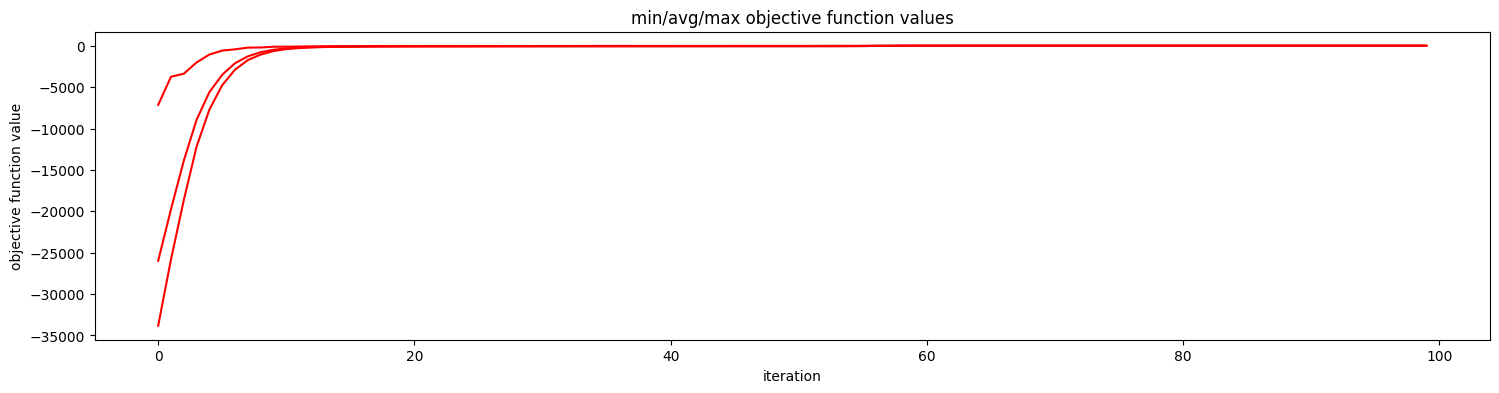

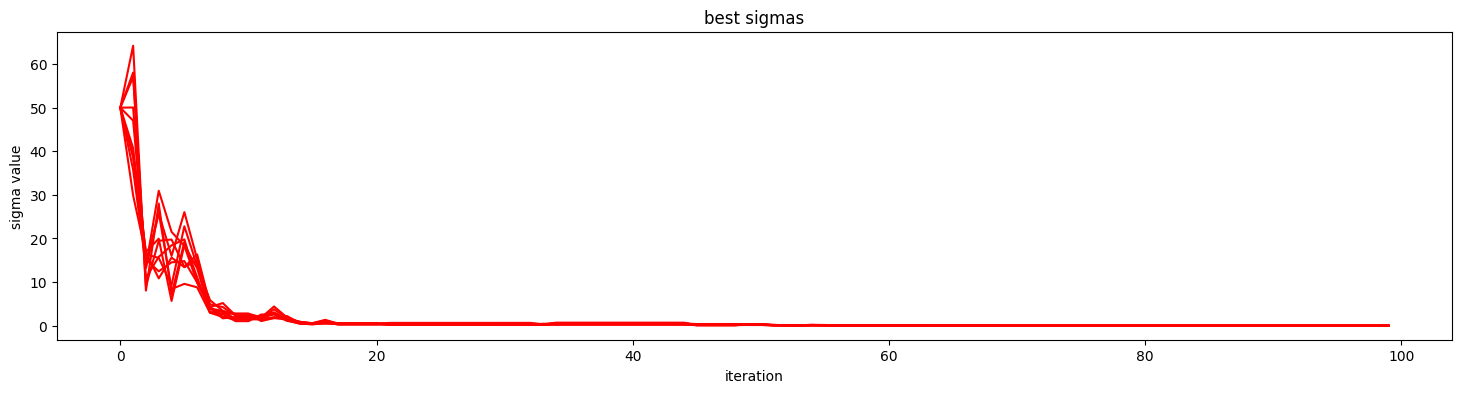

In [25]:
d = 10
N = 2000
T = 100

(
    best_objective_value,
    best_chromosome,
    history_objective_values,
    history_best_chromosome,
    history_best_sigmas,
) = es(
    objective_function_F6,
    d,
    N,
    T,
    2 * N,
    2,
    50.0,
    1 / np.sqrt(2 * d),
    1 / np.sqrt(2 * np.sqrt(d)),
    10,
)

plt.figure(figsize=(18, 4))
plt.plot(history_objective_values[:, 0], "r-")
plt.plot(history_objective_values[:, 1], "r-")
plt.plot(history_objective_values[:, 2], "r-")
plt.xlabel("iteration")
plt.ylabel("objective function value")
plt.title("min/avg/max objective function values")
plt.show()

plt.figure(figsize=(18, 4))
plt.plot(history_best_sigmas, "r-")
plt.xlabel("iteration")
plt.ylabel("sigma value")
plt.title("best sigmas")
plt.show()

### Działanie strategii ewolucyjnej dla funkcji Griewanka F8

Iteration 0000 : best score = -2.05438008, mean score = -7.60432933.
Iteration 0001 : best score = -1.61331080, mean score = -6.05163221.
Iteration 0002 : best score = -1.61331080, mean score = -4.59800090.
Iteration 0003 : best score = -1.40225163, mean score = -3.40323959.
Iteration 0004 : best score = -1.24601888, mean score = -2.52701876.
Iteration 0005 : best score = -1.11474527, mean score = -1.93827785.
Iteration 0006 : best score = -1.09037958, mean score = -1.56138468.
Iteration 0007 : best score = -0.77897549, mean score = -1.33078082.
Iteration 0008 : best score = -0.68960125, mean score = -1.18753400.
Iteration 0009 : best score = -0.62102882, mean score = -1.10553873.
Iteration 0010 : best score = -0.53779039, mean score = -1.05795343.
Iteration 0011 : best score = -0.48554540, mean score = -1.02887553.
Iteration 0012 : best score = -0.48554540, mean score = -1.01170065.
Iteration 0013 : best score = -0.47468467, mean score = -0.99768936.
Iteration 0014 : best score = -0.4

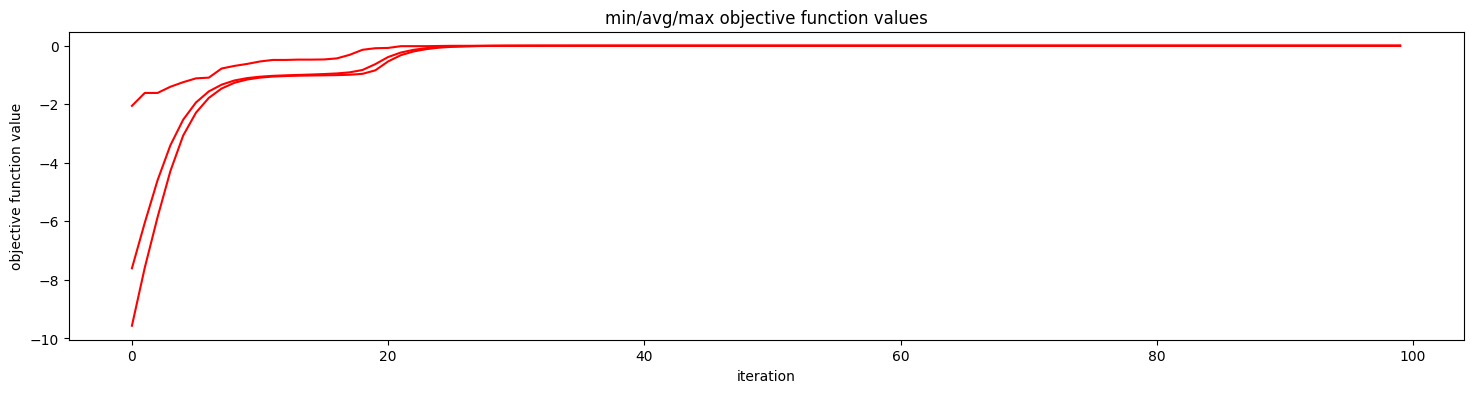

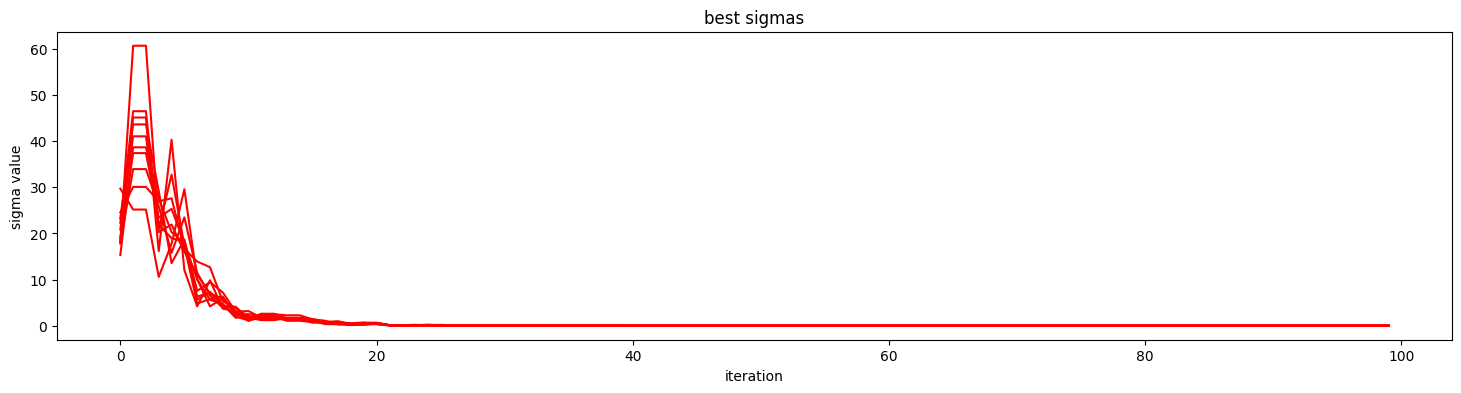

In [26]:
d = 10
N = 2000
T = 100

(
    best_objective_value,
    best_chromosome,
    history_objective_values,
    history_best_chromosome,
    history_best_sigmas,
) = es(
    objective_function_F8,
    d,
    N,
    T,
    2 * N,
    2,
    50.0,
    1 / np.sqrt(2 * d),
    1 / np.sqrt(2 * np.sqrt(d)),
    10,
)

plt.figure(figsize=(18, 4))
plt.plot(history_objective_values[:, 0], "r-")
plt.plot(history_objective_values[:, 1], "r-")
plt.plot(history_objective_values[:, 2], "r-")
plt.xlabel("iteration")
plt.ylabel("objective function value")
plt.title("min/avg/max objective function values")
plt.show()

plt.figure(figsize=(18, 4))
plt.plot(history_best_sigmas, "r-")
plt.xlabel("iteration")
plt.ylabel("sigma value")
plt.title("best sigmas")
plt.show()

# Zadanie 1

In [27]:
benchmark_functions = {
    "Sphere_F1": objective_function_F1,
    "Rastrigin_F6": objective_function_F6,
    "Schwefel_F7": objective_function_F7,
    "Griewank_F8": objective_function_F8,
}


dims = [10, 20, 50, 100]
pop_sizes = [200, 1000]
sigmas = [10.0, 50.0]
T = 200
num_runs = 3

results = []

for func_name, func in benchmark_functions.items():
    for d in dims:
        tau = 1.0 / np.sqrt(2.0 * d)
        tau_0 = 1.0 / np.sqrt(2.0 * np.sqrt(d))

        for N in pop_sizes:
            for sigma in sigmas:
                for run in range(num_runs):
                    print(
                        f"Running {func_name}, d={d}, N={N}, sigma={sigma}, run={run + 1}/{num_runs}"
                    )

                    best_objective_value, best_chromosome, _, _, _ = es(
                        objective_function=func,
                        chromosome_length=d,
                        population_size=N,
                        number_of_iterations=T,
                        number_of_offspring=2 * N,
                        number_of_parents=2,
                        sigma=sigma,
                        tau=tau,
                        tau_0=tau_0,
                        log_frequency=-1,  # disable logging
                    )

                    results.append(
                        {
                            "function": func_name,
                            "dim": d,
                            "N": N,
                            "sigma": sigma,
                            "best_objective_value": best_objective_value,
                        }
                    )


df_results = pd.DataFrame(results)

Running Sphere_F1, d=10, N=200, sigma=10.0, run=1/3
Running Sphere_F1, d=10, N=200, sigma=10.0, run=2/3
Running Sphere_F1, d=10, N=200, sigma=10.0, run=3/3
Running Sphere_F1, d=10, N=200, sigma=50.0, run=1/3
Running Sphere_F1, d=10, N=200, sigma=50.0, run=2/3
Running Sphere_F1, d=10, N=200, sigma=50.0, run=3/3
Running Sphere_F1, d=10, N=1000, sigma=10.0, run=1/3
Running Sphere_F1, d=10, N=1000, sigma=10.0, run=2/3
Running Sphere_F1, d=10, N=1000, sigma=10.0, run=3/3
Running Sphere_F1, d=10, N=1000, sigma=50.0, run=1/3
Running Sphere_F1, d=10, N=1000, sigma=50.0, run=2/3
Running Sphere_F1, d=10, N=1000, sigma=50.0, run=3/3
Running Sphere_F1, d=20, N=200, sigma=10.0, run=1/3
Running Sphere_F1, d=20, N=200, sigma=10.0, run=2/3
Running Sphere_F1, d=20, N=200, sigma=10.0, run=3/3
Running Sphere_F1, d=20, N=200, sigma=50.0, run=1/3
Running Sphere_F1, d=20, N=200, sigma=50.0, run=2/3
Running Sphere_F1, d=20, N=200, sigma=50.0, run=3/3
Running Sphere_F1, d=20, N=1000, sigma=10.0, run=1/3
Runni

In [28]:
df_results

,function,dim,N,sigma,best_objective_value
0,Sphere_F1,10,200,10.0,-1.885493e-44
1,Sphere_F1,10,200,10.0,-1.013970e-42
2,Sphere_F1,10,200,10.0,-6.250216e-43
3,Sphere_F1,10,200,50.0,-1.998822e-44
4,Sphere_F1,10,200,50.0,-1.696598e-42
...,...,...,...,...,...
187,Griewank_F8,100,1000,10.0,-1.325951e-01
188,Griewank_F8,100,1000,10.0,-9.926060e-02
189,Griewank_F8,100,1000,50.0,-1.071436e-01
190,Griewank_F8,100,1000,50.0,-1.060433e-01


In [29]:
summary = (
    df_results.groupby(["function", "dim", "N", "sigma"])["best_objective_value"]
    .agg(["mean", "min", "max"])
    .reset_index()
)

summary

,function,dim,N,sigma,mean,min,max
0,Griewank_F8,10,200,10.0,-1.804835e-02,-3.446731e-02,0.000000e+00
1,Griewank_F8,10,200,50.0,-1.560347e-02,-2.463706e-02,-9.857285e-03
2,Griewank_F8,10,1000,10.0,-4.930694e-03,-7.396040e-03,0.000000e+00
3,Griewank_F8,10,1000,50.0,-4.926592e-03,-1.477978e-02,0.000000e+00
4,Griewank_F8,20,200,10.0,-4.926592e-03,-1.477978e-02,0.000000e+00
...,...,...,...,...,...,...,...
59,Sphere_F1,50,1000,50.0,-2.521872e-07,-4.579070e-07,-8.706709e-08
60,Sphere_F1,100,200,10.0,-1.137858e+01,-1.366420e+01,-1.003365e+01
61,Sphere_F1,100,200,50.0,-9.430465e+00,-2.196700e+01,-2.670925e+00
62,Sphere_F1,100,1000,10.0,-4.226614e-01,-5.123056e-01,-3.244733e-01


# Zadanie 2

In [30]:
def mutation1(x, N, sigma):
    d = len(x)
    return x + sigma * np.random.randn(N, d)


def mutation2(x, N, sigmas):
    d = len(x)
    return x + sigmas * np.random.randn(N, d)


def mutation3(x, N, S):
    d = len(x)
    return x + np.dot(np.random.randn(N, d), np.linalg.cholesky(S).T)

In [31]:
def test_mutation_1(x, obj_f, N=100, sigma=0.25):
    x_fitness = obj_f(np.array([x]))

    mutations = mutation1(x, N, sigma)
    fitness_vals = obj_f(mutations)

    better_cnt = np.sum((fitness_vals > x_fitness))
    best = np.max(fitness_vals)

    return {
        "better_cnt": better_cnt,
        "total": N,
        "improvement": best - x_fitness,
        "best": best,
    }

In [32]:
def test_mutation_2(x, obj_f, sigmas, N=100):
    x_fitness = obj_f(np.array([x]))

    mutations = mutation2(x, N, sigmas)
    fitness_vals = obj_f(mutations)

    better_cnt = np.sum((fitness_vals > x_fitness))
    best = np.max(fitness_vals)

    return {
        "better_cnt": better_cnt,
        "total": N,
        "improvement": best - x_fitness,
        "best": best,
    }

In [33]:
def test_mutation_3(x, obj_f, S, N=100):
    x_fitness = obj_f(np.array([x]))

    mutations = mutation3(x, N, S)
    fitness_vals = obj_f(mutations)

    better_cnt = np.sum((fitness_vals > x_fitness))
    best = np.max(fitness_vals)

    return {
        "better_cnt": better_cnt,
        "total": N,
        "improvement": best - x_fitness,
        "best": best,
    }

In [34]:
def run_tests(d, obj_f, bounds, repeats=100):
    low, high = bounds
    stats = {
        "m1": {"better_cnts": [], "improvements": []},
        "m2": {"better_cnts": [], "improvements": []},
        "m3": {"better_cnts": [], "improvements": []},
    }

    sigma_m1 = 1
    sigmas_m2 = np.random.uniform(0.1, 1.0, d)

    A = np.random.rand(d, d)
    S_m3 = np.dot(A, A.transpose())

    for i in range(repeats):
        x_start = np.random.uniform(low, high, size=d)

        res1 = test_mutation_1(x_start, obj_f, N=100, sigma=sigma_m1)
        res2 = test_mutation_2(x_start, obj_f, sigmas=sigmas_m2, N=100)
        res3 = test_mutation_3(x_start, obj_f, S=S_m3, N=100)

        stats["m1"]["better_cnts"].append(res1["better_cnt"])
        stats["m1"]["improvements"].append(res1["improvement"])

        stats["m2"]["better_cnts"].append(res2["better_cnt"])
        stats["m2"]["improvements"].append(res2["improvement"])

        stats["m3"]["better_cnts"].append(res3["better_cnt"])
        stats["m3"]["improvements"].append(res3["improvement"])

    print(f"--- N={repeats}, d={d} ---")
    for model in ["m1", "m2", "m3"]:
        avg_count = np.mean(stats[model]["better_cnts"])
        avg_imp = np.mean(stats[model]["improvements"])
        print(
            f"[{model.upper()}] Avg individuals better: {avg_count:.2f}% | Avg best fitness gain: {avg_imp:.4f}"
        )

In [35]:
print("Sphere")
run_tests(d=10, obj_f=objective_function_F1, bounds=(-5.12, 5.12))

Sphere
--- N=100, d=10 ---
[M1] Avg individuals better: 31.88% | Avg best fitness gain: 32.3863
[M2] Avg individuals better: 39.32% | Avg best fitness gain: 21.8354
[M3] Avg individuals better: 22.94% | Avg best fitness gain: 27.4217


In [36]:
print("Rastrigin")
run_tests(d=10, obj_f=objective_function_F6, bounds=(-5.12, 5.12))

Rastrigin
--- N=100, d=10 ---
[M1] Avg individuals better: 38.23% | Avg best fitness gain: 59.6129
[M2] Avg individuals better: 41.60% | Avg best fitness gain: 54.5322
[M3] Avg individuals better: 28.92% | Avg best fitness gain: 56.7904


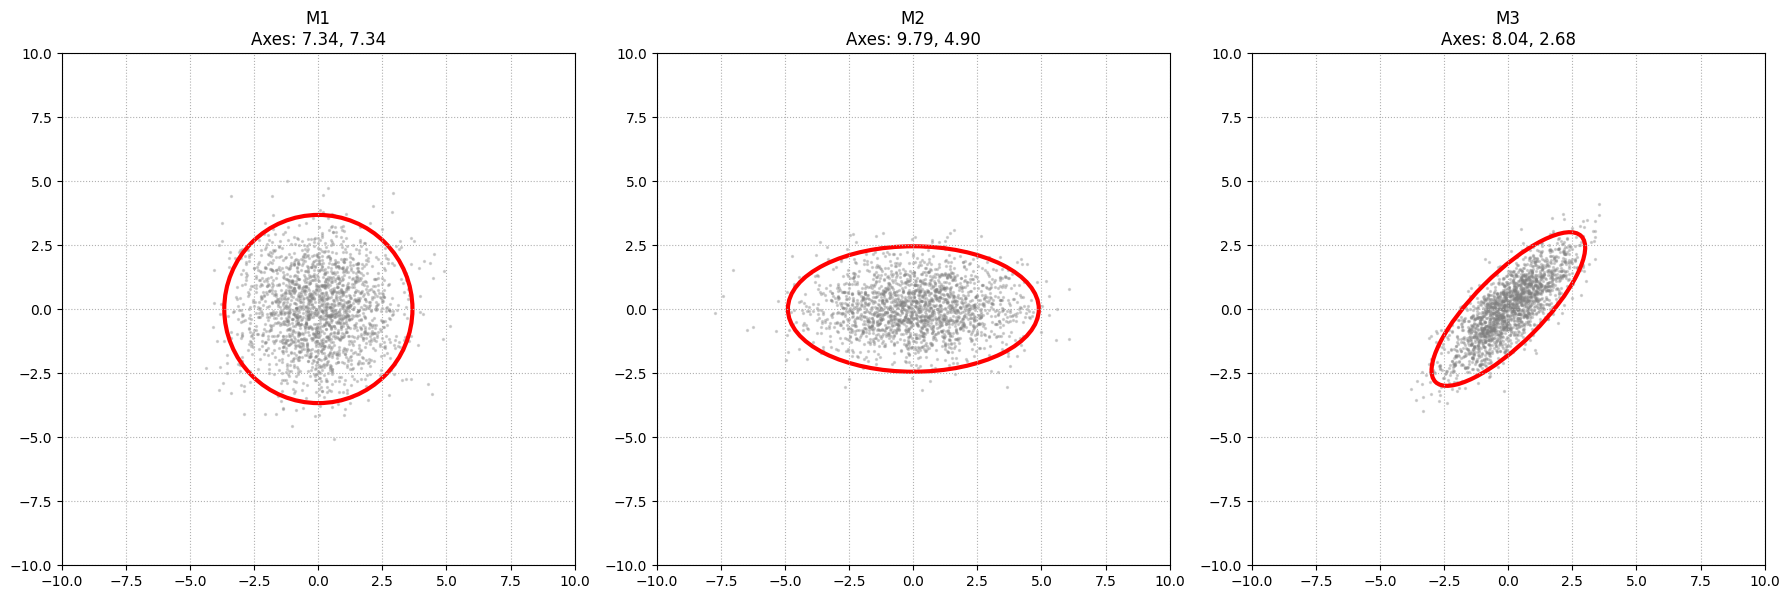

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import chi2


def get_ellipse(cov_matrix, alpha=0.95):
    chi2_val = chi2.ppf(alpha, df=2)
    scale_factor = np.sqrt(chi2_val)
    eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)

    width = 2 * scale_factor * np.sqrt(eig_vals[1])
    height = 2 * scale_factor * np.sqrt(eig_vals[0])

    largest_eigenvec = eig_vecs[:, 1]
    angle = np.degrees(np.arctan2(largest_eigenvec[1], largest_eigenvec[0]))

    return width, height, angle


N = 2000
alpha = 0.95
center = [0, 0]


sigma_1 = 1.5
S1 = (sigma_1**2) * np.identity(2)
points1 = np.random.randn(N, 2) @ np.linalg.cholesky(S1).T

sigmas_2 = [2.0, 1.0]
S2 = np.diag(np.array(sigmas_2) ** 2)
points2 = np.random.randn(N, 2) @ np.linalg.cholesky(S2).T


S3 = np.array([[1.5, 1.2], [1.2, 1.5]])
points3 = np.random.randn(N, 2) @ np.linalg.cholesky(S3).T


matrices = [S1, S2, S3]
points_list = [points1, points2, points3]
titles = ["M1", "M2", "M3"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, ax in enumerate(axes):
    S = matrices[i]
    pts = points_list[i]

    ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.3, color="gray")

    w, h, angle = get_ellipse(S, alpha=alpha)

    ell = Ellipse(
        xy=center,
        width=w,
        height=h,
        angle=angle,
        edgecolor="red",
        facecolor="none",
        lw=3,
    )
    ax.add_patch(ell)

    ax.set_title(f"{titles[i]}\nAxes: {w:.2f}, {h:.2f}")
    ax.set_aspect("equal")
    limit = 10
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.grid(True, linestyle=":")

plt.tight_layout()
plt.show()

# Zadanie 3

In [38]:
def run_sphere_benchmark(mutation_model, S=None):
    benchmark_functions = {
        "Sphere_F1a": objective_function_F1a,
        "Sphere_F1b": objective_function_F1b,
        "Sphere_F1c": objective_function_F1c,
    }

    dims = [2]
    pop_sizes = [200, 1000]
    sigmas = [10.0, 50.0]
    T = 200
    num_runs = 3

    results = []

    for func_name, func in benchmark_functions.items():
        for d in dims:
            tau = 1.0 / np.sqrt(2.0 * d)
            tau_0 = 1.0 / np.sqrt(2.0 * np.sqrt(d))

            for N in pop_sizes:
                for sigma in sigmas:
                    for run in range(num_runs):
                        print(
                            f"Running {func_name}, d={d}, N={N}, sigma={sigma}, run={run + 1}/{num_runs}"
                        )

                        best_objective_value, best_chromosome, _, _, _ = es(
                            objective_function=func,
                            chromosome_length=d,
                            population_size=N,
                            number_of_iterations=T,
                            number_of_offspring=2 * N,
                            number_of_parents=2,
                            sigma=sigma,
                            tau=tau,
                            tau_0=tau_0,
                            S=S,
                            mutation_f=mutation_model,
                            log_frequency=-1,  # disable logging
                        )

                        results.append(
                            {
                                "function": func_name,
                                "dim": d,
                                "N": N,
                                "sigma": sigma,
                                "best_objective_value": best_objective_value,
                            }
                        )

    return pd.DataFrame(results)

In [39]:
run_sphere_benchmark("mutation_1")

Running Sphere_F1a, d=2, N=200, sigma=10.0, run=1/3
Running Sphere_F1a, d=2, N=200, sigma=10.0, run=2/3
Running Sphere_F1a, d=2, N=200, sigma=10.0, run=3/3
Running Sphere_F1a, d=2, N=200, sigma=50.0, run=1/3
Running Sphere_F1a, d=2, N=200, sigma=50.0, run=2/3
Running Sphere_F1a, d=2, N=200, sigma=50.0, run=3/3
Running Sphere_F1a, d=2, N=1000, sigma=10.0, run=1/3
Running Sphere_F1a, d=2, N=1000, sigma=10.0, run=2/3
Running Sphere_F1a, d=2, N=1000, sigma=10.0, run=3/3
Running Sphere_F1a, d=2, N=1000, sigma=50.0, run=1/3
Running Sphere_F1a, d=2, N=1000, sigma=50.0, run=2/3
Running Sphere_F1a, d=2, N=1000, sigma=50.0, run=3/3
Running Sphere_F1b, d=2, N=200, sigma=10.0, run=1/3
Running Sphere_F1b, d=2, N=200, sigma=10.0, run=2/3
Running Sphere_F1b, d=2, N=200, sigma=10.0, run=3/3
Running Sphere_F1b, d=2, N=200, sigma=50.0, run=1/3
Running Sphere_F1b, d=2, N=200, sigma=50.0, run=2/3
Running Sphere_F1b, d=2, N=200, sigma=50.0, run=3/3
Running Sphere_F1b, d=2, N=1000, sigma=10.0, run=1/3
Runni

,function,dim,N,sigma,best_objective_value
0,Sphere_F1a,2,200,10.0,-2.599984e-83
1,Sphere_F1a,2,200,10.0,-1.125130e-84
2,Sphere_F1a,2,200,10.0,-4.988292e-84
3,Sphere_F1a,2,200,50.0,-7.459106e-85
4,Sphere_F1a,2,200,50.0,-5.938215e-85
5,Sphere_F1a,2,200,50.0,-2.501126e-83
6,Sphere_F1a,2,1000,10.0,-2.588060e-86
7,Sphere_F1a,2,1000,10.0,-3.566809e-87
8,Sphere_F1a,2,1000,10.0,-3.591643e-86
9,Sphere_F1a,2,1000,50.0,-1.564292e-85


In [40]:
run_sphere_benchmark("mutation_2")

Running Sphere_F1a, d=2, N=200, sigma=10.0, run=1/3
Running Sphere_F1a, d=2, N=200, sigma=10.0, run=2/3
Running Sphere_F1a, d=2, N=200, sigma=10.0, run=3/3
Running Sphere_F1a, d=2, N=200, sigma=50.0, run=1/3
Running Sphere_F1a, d=2, N=200, sigma=50.0, run=2/3
Running Sphere_F1a, d=2, N=200, sigma=50.0, run=3/3
Running Sphere_F1a, d=2, N=1000, sigma=10.0, run=1/3
Running Sphere_F1a, d=2, N=1000, sigma=10.0, run=2/3
Running Sphere_F1a, d=2, N=1000, sigma=10.0, run=3/3
Running Sphere_F1a, d=2, N=1000, sigma=50.0, run=1/3
Running Sphere_F1a, d=2, N=1000, sigma=50.0, run=2/3
Running Sphere_F1a, d=2, N=1000, sigma=50.0, run=3/3
Running Sphere_F1b, d=2, N=200, sigma=10.0, run=1/3
Running Sphere_F1b, d=2, N=200, sigma=10.0, run=2/3
Running Sphere_F1b, d=2, N=200, sigma=10.0, run=3/3
Running Sphere_F1b, d=2, N=200, sigma=50.0, run=1/3
Running Sphere_F1b, d=2, N=200, sigma=50.0, run=2/3
Running Sphere_F1b, d=2, N=200, sigma=50.0, run=3/3
Running Sphere_F1b, d=2, N=1000, sigma=10.0, run=1/3
Runni

,function,dim,N,sigma,best_objective_value
0,Sphere_F1a,2,200,10.0,-1.772305e-71
1,Sphere_F1a,2,200,10.0,-1.979990e-71
2,Sphere_F1a,2,200,10.0,-3.636954e-70
3,Sphere_F1a,2,200,50.0,-2.770788e-69
4,Sphere_F1a,2,200,50.0,-2.524021e-70
5,Sphere_F1a,2,200,50.0,-6.865688e-70
6,Sphere_F1a,2,1000,10.0,-3.300432e-73
7,Sphere_F1a,2,1000,10.0,-2.857575e-73
8,Sphere_F1a,2,1000,10.0,-4.388466e-72
9,Sphere_F1a,2,1000,50.0,-1.441006e-71


In [44]:
A = np.random.rand(2, 2)
S = np.dot(A, A.transpose())
run_sphere_benchmark("mutation_3", S)

Running Sphere_F1a, d=2, N=200, sigma=10.0, run=1/3
Running Sphere_F1a, d=2, N=200, sigma=10.0, run=2/3
Running Sphere_F1a, d=2, N=200, sigma=10.0, run=3/3
Running Sphere_F1a, d=2, N=200, sigma=50.0, run=1/3
Running Sphere_F1a, d=2, N=200, sigma=50.0, run=2/3
Running Sphere_F1a, d=2, N=200, sigma=50.0, run=3/3
Running Sphere_F1a, d=2, N=1000, sigma=10.0, run=1/3
Running Sphere_F1a, d=2, N=1000, sigma=10.0, run=2/3
Running Sphere_F1a, d=2, N=1000, sigma=10.0, run=3/3
Running Sphere_F1a, d=2, N=1000, sigma=50.0, run=1/3
Running Sphere_F1a, d=2, N=1000, sigma=50.0, run=2/3
Running Sphere_F1a, d=2, N=1000, sigma=50.0, run=3/3
Running Sphere_F1b, d=2, N=200, sigma=10.0, run=1/3
Running Sphere_F1b, d=2, N=200, sigma=10.0, run=2/3
Running Sphere_F1b, d=2, N=200, sigma=10.0, run=3/3
Running Sphere_F1b, d=2, N=200, sigma=50.0, run=1/3
Running Sphere_F1b, d=2, N=200, sigma=50.0, run=2/3
Running Sphere_F1b, d=2, N=200, sigma=50.0, run=3/3
Running Sphere_F1b, d=2, N=1000, sigma=10.0, run=1/3
Runni

,function,dim,N,sigma,best_objective_value
0,Sphere_F1a,2,200,10.0,-1.982993e-84
1,Sphere_F1a,2,200,10.0,-1.077873e-83
2,Sphere_F1a,2,200,10.0,-2.971399e-85
3,Sphere_F1a,2,200,50.0,-3.737101e-85
4,Sphere_F1a,2,200,50.0,-4.327952e-85
5,Sphere_F1a,2,200,50.0,-7.705072e-84
6,Sphere_F1a,2,1000,10.0,-4.703968e-86
7,Sphere_F1a,2,1000,10.0,-6.121161e-86
8,Sphere_F1a,2,1000,10.0,-8.759318e-86
9,Sphere_F1a,2,1000,50.0,-3.523143e-85
